In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_train = pd.read_csv('../data/train.csv')
df_metadata = pd.read_csv('../data/metaData.csv')
df_train.sample(5)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
108,52259907,2,3.289158,0,21.829279,0.0,0.0,0.0,3.128044,0.0,...,0.0,0.969065,0.969065,0.0,0.0,1,0,7,43.846683,1
178,80265452,1,0.000000,1,188.783646,0.0,0.0,0.0,5.245885,0.0,...,0.0,0.000000,0.000000,0.0,0.0,1,0,6,62.885322,0
104,51167521,1,0.000000,1,16.023645,0.0,0.0,0.0,2.834603,0.0,...,0.0,0.000000,0.000000,0.0,0.0,3,6,7,64.068341,0
197,86806129,1,0.000000,1,457.481128,0.0,0.0,0.0,6.127919,0.0,...,0.0,0.000000,0.000000,0.0,0.0,18,1,7,21.529544,1
61,34908295,1,0.000000,1,298.486431,0.0,0.0,0.0,5.702069,0.0,...,0.0,0.000000,0.000000,0.0,0.0,21,0,7,63.960796,0


In [4]:
# COLUMN TYPE GROUPING


# TARGET + IDENTIFIER


ID_COL = ["event_id"]
TARGET_COLS = ["time_to_hit_hours", "event"]


# CATEGORICAL COUNT FEATURES


categorical_count = [
    "num_perimeters_0_5h"
]


# TIME / TEMPORAL FEATURES


time_features = [
    "dt_first_last_0_5h",
    "event_start_hour",
    "event_start_dayofweek",
    "event_start_month"
]


# BINARY / LOW CARDINALITY FEATURES


categorical = [
    "low_temporal_resolution_0_5h"
]


# CONTINUOUS FEATURES


continuous = [
    "area_first_ha",
    "area_growth_abs_0_5h",
    "area_growth_rel_0_5h",
    "area_growth_rate_ha_per_h",
    "log1p_area_first",
    "log1p_growth",
    "log_area_ratio_0_5h",
    "relative_growth_0_5h",
    "radial_growth_m",
    "radial_growth_rate_m_per_h",
    "centroid_displacement_m",
    "centroid_speed_m_per_h",
    "spread_bearing_deg",
    "spread_bearing_sin",
    "spread_bearing_cos",
    "dist_min_ci_0_5h",
    "dist_std_ci_0_5h",
    "dist_change_ci_0_5h",
    "dist_slope_ci_0_5h",
    "closing_speed_m_per_h",
    "closing_speed_abs_m_per_h",
    "projected_advance_m",
    "dist_accel_m_per_h2",
    "dist_fit_r2_0_5h",
    "alignment_cos",
    "alignment_abs",
    "cross_track_component",
    "along_track_speed"
]


# ALL FEATURES


ALL_FEATURES = continuous + categorical + categorical_count + time_features

print("Continuous:", len(continuous))
print("Categorical:", len(categorical))
print("Categorical Count:", len(categorical_count))
print("Time Features:", len(time_features))
print("Total Features:", len(ALL_FEATURES))


Continuous: 28
Categorical: 1
Categorical Count: 1
Time Features: 4
Total Features: 34


# Target Distribution

Text(0.5, 1.0, 'Distribution of Event (Hit vs No Hit)')

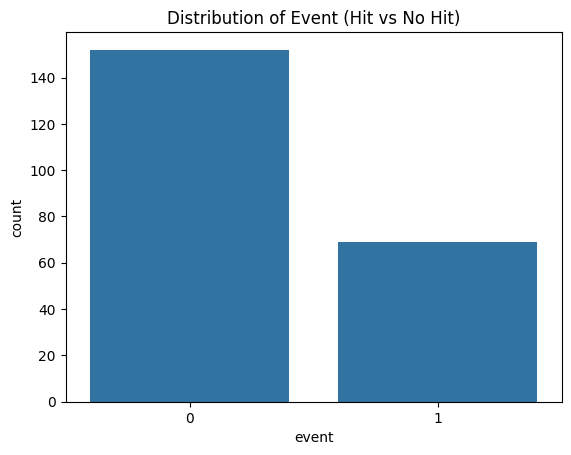

In [24]:
sns.countplot(data=df_train, x="event")
plt.title("Distribution of Event (Hit vs No Hit)")

Most fires did NOT reach evacuation zones.
Dataset is imbalanced.

# Time-to-Hit Distribution

Text(0.5, 1.0, 'Distribution of Time to Hit Evacuation Zone')

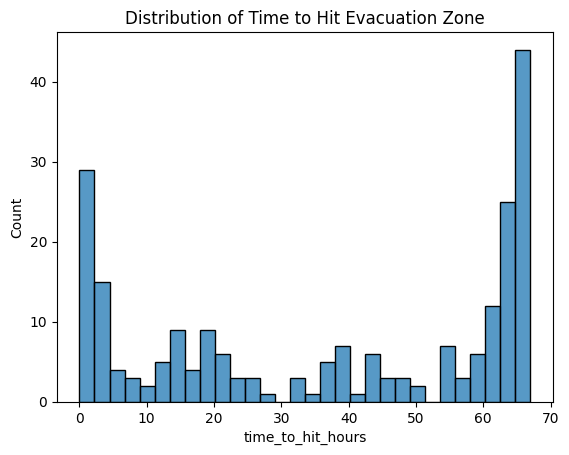

In [25]:
sns.histplot(df_train["time_to_hit_hours"], bins=30)
plt.title("Distribution of Time to Hit Evacuation Zone")

### Distribution of Time to Hit Evacuation Zone

The histogram of `time_to_hit_hours` shows a bimodal distribution. One cluster of observations appears at very low time values (0–10 hours), representing fires that reach evacuation zones quickly after ignition. Another large cluster appears near the upper limit of the observation window (around 60–72 hours), which corresponds to fires that did not reach evacuation zones within the monitoring period.

This pattern reflects the survival nature of the dataset: some fires escalate rapidly and reach populated areas quickly, while many others never approach evacuation zones within the 72-hour window.

`HINDI`<br>
ya fire jaldi dangerous ban jati hai
ya phir evacuation zone tak pahunchti hi nahi

# Distance vs Event

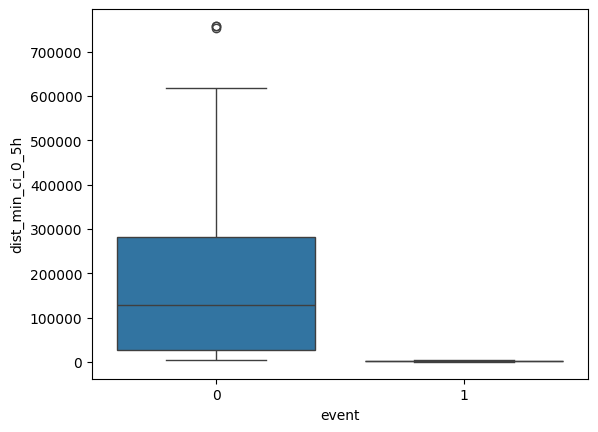

In [27]:
sns.boxplot(
    data=df_train,
    x="event",
    y="dist_min_ci_0_5h"
)
plt.show()

### Distance to Evacuation Zone vs Event Outcome

The boxplot compares the distribution of `dist_min_ci_0_5h` (minimum distance to the nearest evacuation zone centroid during the first 5 hours) for fires that **did not reach the evacuation zone (event = 0)** and fires that **did reach the evacuation zone (event = 1)**.

#### Key Observations

1. **Fires that reached evacuation zones start much closer**
   
   Fires with `event = 1` generally have very small distances to evacuation zones during the first five hours. This suggests that fires which eventually threaten evacuation zones are typically already located relatively close to populated areas.

2. **Censored fires are usually far away**
   
   For `event = 0`, the distances are much larger and widely distributed. Many of these fires occur tens or even hundreds of kilometers away from evacuation zones, making it unlikely that they reach the threshold within the observation window.

3. **High variability among non-event fires**
   
   The distribution for `event = 0` shows a large spread and several extreme values (outliers), indicating that some fires ignite extremely far from evacuation zones.

#### Interpretation

Distance to evacuation zones appears to be a **strong indicator of wildfire risk**. Fires that begin closer to evacuation zones have a much higher likelihood of reaching them within the 72-hour window.

---

### Simple Understanding (Hindi)

Simple language me:

- Jo fires **evacuation zone ke paas start hoti hain**, unka **event = 1** hone ka chance zyada hai.  
- Jo fires **bahut door start hoti hain**, wo usually **72 hours me evacuation zone tak nahi pahunchti**.  
- Isliye `dist_min_ci_0_5h` wildfire risk prediction ke liye **important feature ho sakta hai**.

# Growth vs Event

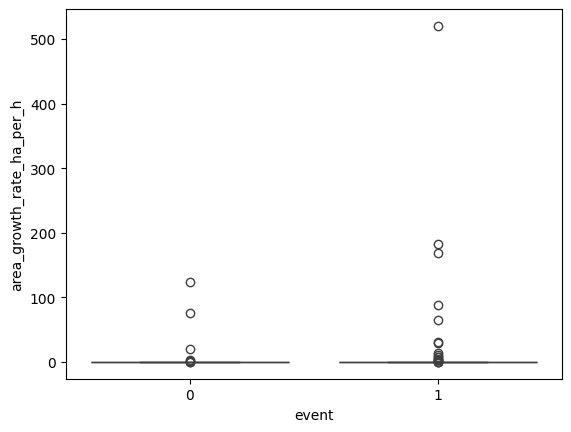

In [28]:
sns.boxplot(
    data=df_train,
    x="event",
    y="area_growth_rate_ha_per_h"
)
plt.show()

### Fire Growth Rate vs Event Outcome

This boxplot compares the distribution of `area_growth_rate_ha_per_h` (fire area growth rate in hectares per hour) between fires that **did not reach evacuation zones (event = 0)** and fires that **did reach evacuation zones (event = 1)**.

#### Key Observations

1. **Most fires show very low early growth rates**

   For both event groups, the majority of values are concentrated near zero. This indicates that many fires do not exhibit significant measurable expansion during the first five hours after ignition.

2. **Higher growth rates appear more frequently in event fires**

   Fires that eventually reach evacuation zones (`event = 1`) show several higher growth-rate values compared to non-event fires. This suggests that rapidly expanding fires may have a higher likelihood of approaching populated areas.

3. **Presence of extreme growth outliers**

   A few fires display extremely high growth rates, particularly in the event group. These cases represent rapidly spreading fires that may pose higher risk.

#### Interpretation

Early fire growth rate may be an important indicator of wildfire progression. Fires that expand more rapidly in the early hours may have a greater chance of reaching evacuation zones within the observation window.

---

### Simple Understanding (Hindi)

Simple language me:

- Zyada tar fires **early stage me slow grow karti hain**.
- Lekin kuch fires **bahut fast grow karti hain**, aur wahi **evacuation zones ke paas pahunch sakti hain**.
- Isliye **fire growth rate early risk prediction me useful signal ho sakta hai**.

# Closing Speed vs Event

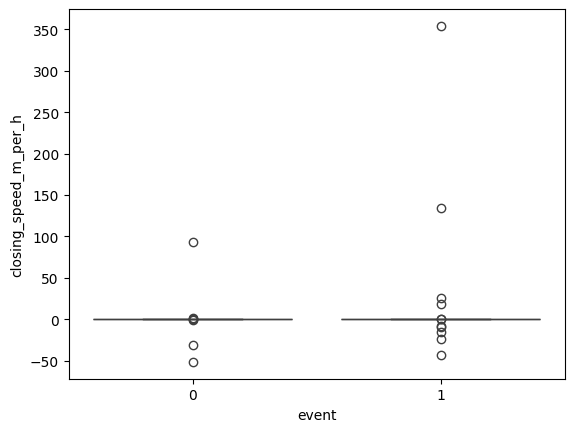

In [29]:
sns.boxplot(
    data=df_train,
    x="event",
    y="closing_speed_m_per_h"
)
plt.show()

### Closing Speed Toward Evacuation Zones vs Event Outcome

This boxplot compares the distribution of `closing_speed_m_per_h`, which represents how quickly a fire is moving toward an evacuation zone, between fires that **did not reach the evacuation zone (event = 0)** and fires that **did reach the evacuation zone (event = 1)**.

#### Key Observations

1. **Most fires have closing speeds near zero**

   For both groups, the majority of values are clustered around zero, indicating that many fires do not significantly move toward or away from evacuation zones during the first five hours.

2. **Higher positive closing speeds appear in event fires**

   Fires with `event = 1` show several larger positive closing speed values. This suggests that fires moving toward evacuation zones more quickly are more likely to eventually reach them.

3. **Negative values indicate movement away from evacuation zones**

   Some fires have negative closing speeds, meaning they are moving away from evacuation zones. These fires are less likely to reach the 5 km threshold within the observation window.

4. **Presence of extreme movement cases**

   A few fires display very high closing speeds, representing rapidly advancing fires that may pose significant risk.

#### Interpretation

Closing speed toward evacuation zones may provide an important signal for wildfire risk assessment. Fires moving toward populated areas at higher speeds are more likely to threaten evacuation zones within the prediction window.

---

### Simple Understanding (Hindi)

Simple language me:

- Zyada tar fires **evacuation zone ki taraf move nahi karti ya bahut slow move karti hain**.
- Agar fire **evacuation zone ki taraf fast move kare**, to uska **event = 1 hone ka chance zyada ho sakta hai**.
- Negative speed ka matlab fire **zone se door move kar rahi hai**, isliye risk kam hota hai.

# Correlation Heatmap

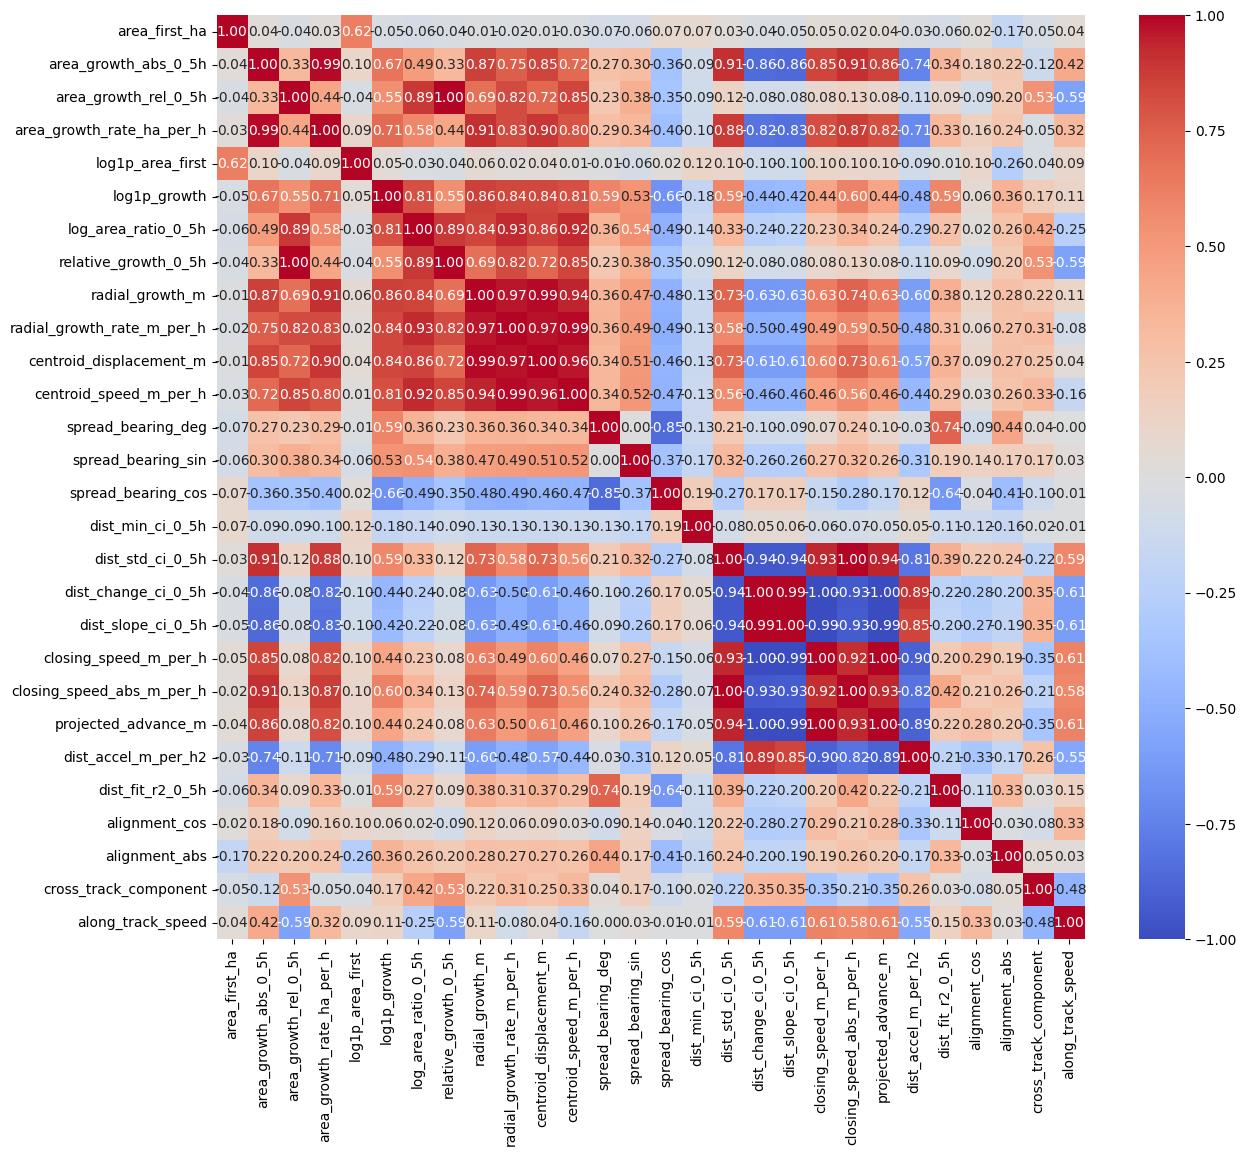

In [31]:
plt.figure(figsize=(14,12))
sns.heatmap(
    df_train[continuous].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)
plt.show()

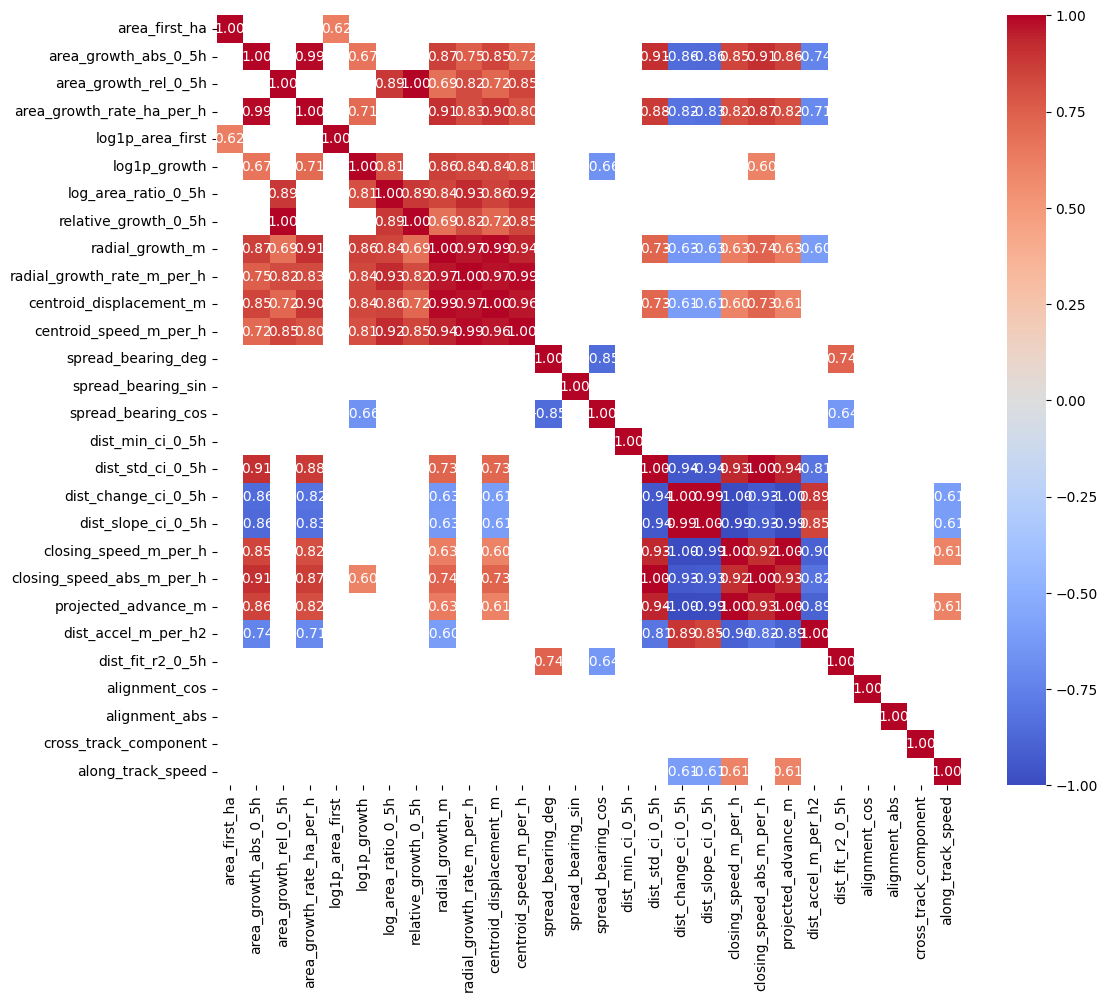

In [35]:
corr = df_train[continuous].corr()

strong_corr = corr[(corr > 0.6) | (corr < -0.6)]

plt.figure(figsize=(12,10))
sns.heatmap(strong_corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

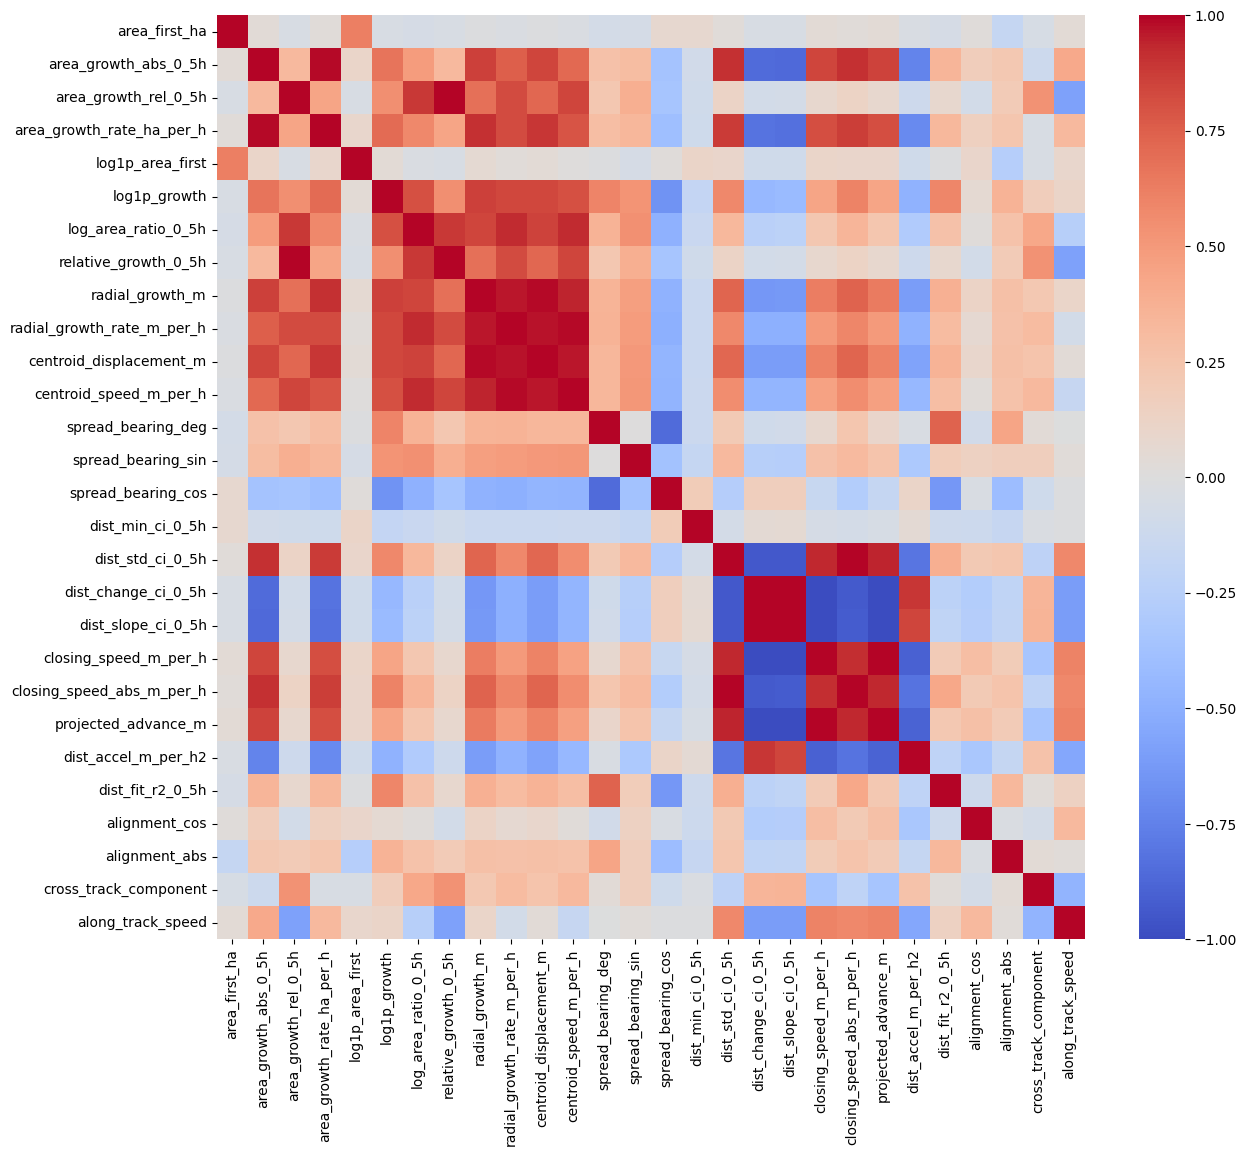

In [33]:
plt.figure(figsize=(14,12))
sns.heatmap(
    df_train[continuous].corr(),
    cmap="coolwarm",
    annot=False
)
plt.show()

In [34]:
corr = df_train[continuous].corr().abs()

top_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

top_corr.head(10)

dist_change_ci_0_5h    projected_advance_m          1.000000
area_growth_rel_0_5h   relative_growth_0_5h         1.000000
dist_change_ci_0_5h    closing_speed_m_per_h        0.998166
closing_speed_m_per_h  projected_advance_m          0.998166
dist_std_ci_0_5h       closing_speed_abs_m_per_h    0.996875
dist_slope_ci_0_5h     closing_speed_m_per_h        0.993135
                       projected_advance_m          0.993057
dist_change_ci_0_5h    dist_slope_ci_0_5h           0.993057
area_growth_abs_0_5h   area_growth_rate_ha_per_h    0.991339
radial_growth_m        centroid_displacement_m      0.989127
dtype: float64

### Perfect Multicollinearity Observed

From the correlation analysis, some feature pairs show **perfect or near-perfect multicollinearity (correlation ≈ 1.0)**.  
This means that these variables contain **almost identical information**.

Examples include:

- `dist_change_ci_0_5h` and `projected_advance_m`
- `area_growth_rel_0_5h` and `relative_growth_0_5h`

Such cases indicate that the same underlying measurement has been represented in multiple ways.

### Note

At this stage of exploratory analysis, all features are retained to fully understand the dataset.  
However, during the **modeling stage**, one variable from each perfectly correlated pair may be **removed to reduce redundancy and improve model stability**, particularly for models sensitive to multicollinearity.



`HINDI`<br>
Kuch features 100% same information de rahe hain.
Isliye later modeling stage me unme se ek feature drop kiya ja sakta hai.
Abhi EDA phase me sab features rakhe gaye hain.